LOADING AND IMPORT LIBRARIES

In [1]:
install.packages(c("stargazer","ggplot2"))
library(stargazer)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 




DATA PREPARATION

In [2]:
p1 <- seq(1,10,by=1)
p2 <- seq(2,11,by=1)
M <- 100
alpha <- 0.35
beta <- 1-alpha

x1 <- (alpha * M)/p1
x2 <- (beta * M)/p2
p1_fix <- 3
p2_fix <- 5
x1_star <- (alpha * M)/p1_fix
x2_star <- (beta * M)/p2_fix
x1_seq <- seq(0.1, M/p1_fix, by = 0.1)
x2_budget <- (M - p1_fix*x1_seq)/p2_fix
utility <- (x1_star^alpha)*(x2_star^beta)
x2_var <- utility^(1/beta) * x1_seq^(-alpha/beta)

df <- data.frame(
  price = p1,
  quantity = x1,
  quantity2 = x2
)
df_budget <- data.frame(
  x1_seq = x1_seq,
  x2_budget = x2_budget
)
df_indiference <- data.frame(
  x1_seq = x1_seq,
  x2_var = x2_var
)
df_optimal <- data.frame(
  x = x1_star,
  y = x2_star
)
cat("CObb douglas demand table\n")
print(df)
cat("\nBudget table\n")
print(head(df_budget,10))
cat("\nIndiference\n")
print(head(df_indiference,10))
cat("\nOptimal\n")
print(head(df_optimal,10))

CObb douglas demand table
   price  quantity quantity2
1      1 35.000000 32.500000
2      2 17.500000 21.666667
3      3 11.666667 16.250000
4      4  8.750000 13.000000
5      5  7.000000 10.833333
6      6  5.833333  9.285714
7      7  5.000000  8.125000
8      8  4.375000  7.222222
9      9  3.888889  6.500000
10    10  3.500000  5.909091

Budget table
   x1_seq x2_budget
1     0.1     19.94
2     0.2     19.88
3     0.3     19.82
4     0.4     19.76
5     0.5     19.70
6     0.6     19.64
7     0.7     19.58
8     0.8     19.52
9     0.9     19.46
10    1.0     19.40

Indiference
   x1_seq    x2_var
1     0.1 168.62218
2     0.2 116.09717
3     0.3  93.32613
4     0.4  79.93345
5     0.5  70.88368
6     0.6  64.25548
7     0.7  59.13736
8     0.8  55.03456
9     0.9  51.65256
10    1.0  48.80375

Optimal
         x  y
1 11.66667 13


DATA VIZ OF COBB DOUGLAS DEMAND CURVE

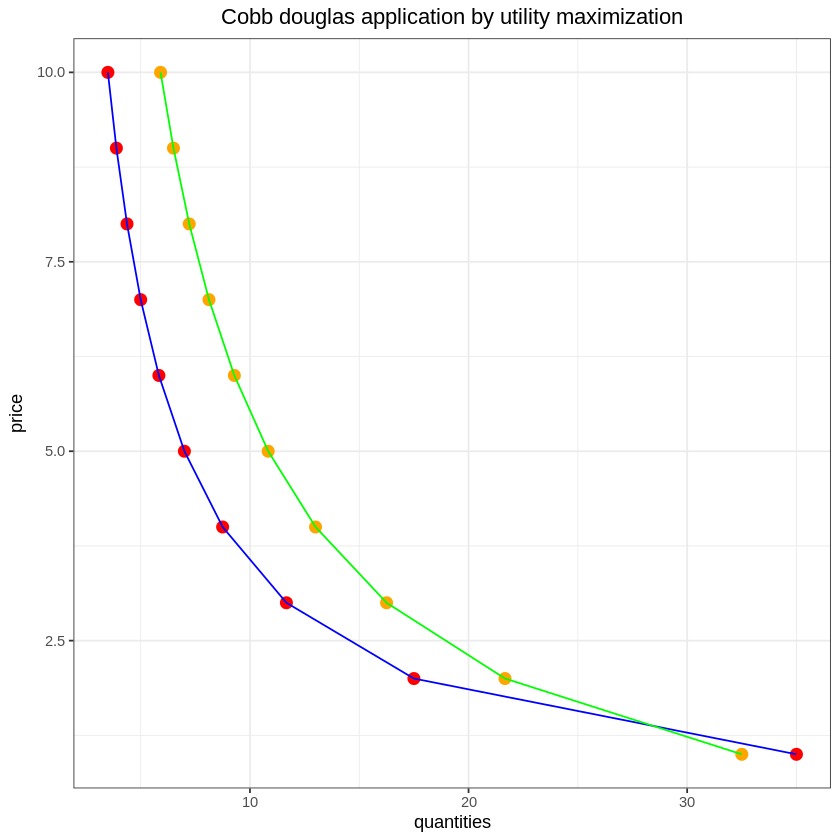

In [3]:
ggplot(data=df)+
  geom_point(aes(x=quantity,y=price),color="red",size=3) +
  geom_line(aes(x=quantity,y=price),color="blue") +
  geom_point(aes(x=quantity2,y=price),color="orange",size=3) +
  geom_line(aes(x=quantity2,y=price),color="green") +
  theme_bw() +
  labs(title="Cobb douglas application by utility maximization",
       x="quantities",
       y="price")+
  theme(plot.title = element_text(hjust= 0.5))

DATA VIZ OF BUDGET LINE

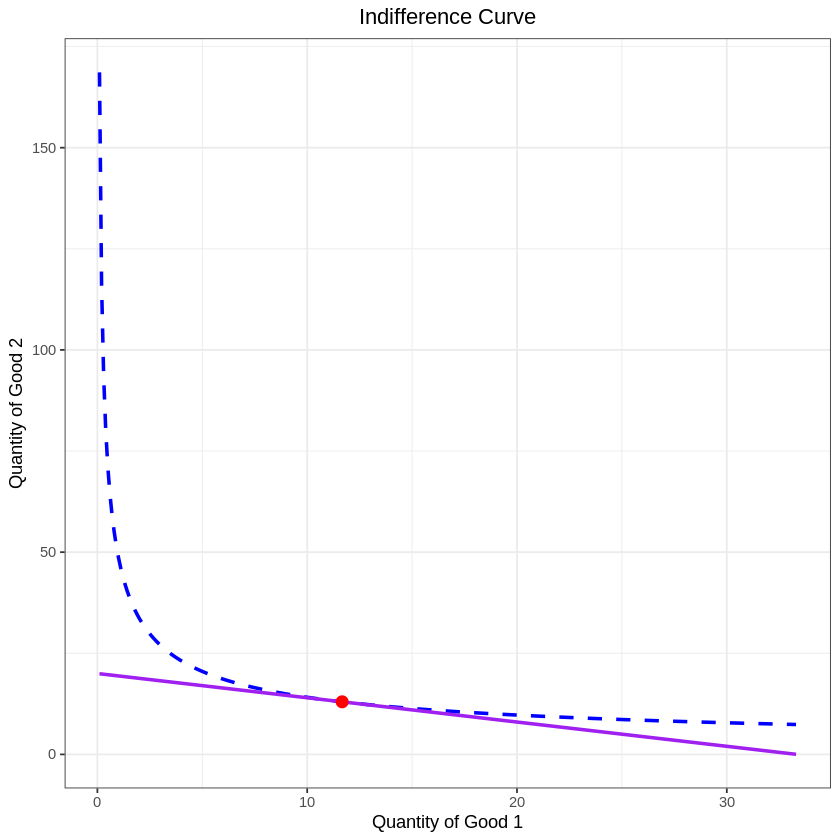

In [5]:
ggplot() +
  geom_line(data = df_indiference,aes(x = x1_seq, y = x2_var), color = "blue", linetype = "dashed", size = 1) +
  theme_bw() +
  labs(title = "Indifference Curve",
       x = "Quantity of Good 1",
       y = "Quantity of Good 2") +
        geom_line(data=df_budget,aes(x = x1_seq, y = x2_budget), color = "purple", size = 1) +
        geom_point(aes(x = x1_star, y = x2_star), color="red", size=3) +

  theme(plot.title = element_text(hjust = 0.5))